In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import pickle
import numpy as np
import tensorflow as tf
from scipy import io as spio
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

ROOTDIR_DATA = "/content/drive/MyDrive/data"

## ResNet18

In [3]:
class Residual(tf.keras.Model):
    """The Residual block of ResNet."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(
            num_channels,
            padding='same',
            kernel_size=3,
            strides=strides)
        self.conv2 = tf.keras.layers.Conv2D(
            num_channels,
            kernel_size=3,
            padding='same')
        self.conv_1x1 = None
        if use_1x1conv:
            self.conv_1x1 = tf.keras.layers.Conv2D(
                num_channels,
                kernel_size=1,
                strides=strides)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, X):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv_1x1 is not None:
            X = self.conv_1x1(X)
        Y += X
        return tf.keras.activations.relu(Y)

class ResnetBlock(tf.keras.layers.Layer):
    def __init__(self, num_channels, num_residuals, downscale=True,
                 **kwargs):
        super(ResnetBlock, self).__init__(**kwargs)
        self.residual_layers = []
        for i in range(num_residuals):
            if i == 0 and downscale:
                self.residual_layers.append(
                    Residual(num_channels, use_1x1conv=True, strides=2))
            else:
                self.residual_layers.append(Residual(num_channels))

    def call(self, X):
        for layer in self.residual_layers:
            X = layer(X)
        return X

class ResNet(tf.keras.Model):

    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlock(64, 2, downscale=False)
        self.block_c = ResnetBlock(128, 2)
        self.block_d = ResnetBlock(256, 2)
        self.block_e = ResnetBlock(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, inputs):
        x = self.block_a(inputs)
        x = self.block_b(x)
        x = self.block_c(x)
        x = self.block_d(x)
        x = self.block_e(x)
        x = self.global_pool(x)
        return self.classifier(x)

# Dataset

In [4]:
(mnist_train, mnist_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)
batch_size = 16
def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., tf.one_hot(label, 10, name='label', axis=-1)

mnist_train = mnist_train.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_train = mnist_train.cache()
mnist_train = mnist_train.shuffle(ds_info.splits['train'].num_examples)
mnist_train = mnist_train.batch(batch_size)
mnist_train = mnist_train.prefetch(tf.data.AUTOTUNE)

`tf.data.Dataset` objects can be converted to `pandas.DataFrame` with tfds.as_dataframe to be visualized on Colab.

N.B. Do not shuffle test dataset

In [5]:
mnist_test = mnist_test.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
mnist_test = mnist_test.cache()
mnist_test = mnist_test.batch(batch_size)
mnist_test = mnist_test.prefetch(tf.data.AUTOTUNE)

# **Assignment #1**: Train and test on MNIST

In [6]:
net = ResNet()
net.build((1, 28, 28, 1))
net.summary()
net.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss = 'categorical_crossentropy',
            metrics = ['accuracy'])
history = net.fit(mnist_train, epochs=10, validation_data=mnist_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "res_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block (ResnetBlock)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_1 (ResnetBlock)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_2 (ResnetBlock)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_3 (ResnetBlock)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 86s 14ms/step - accuracy: 0.9436 - loss: 0.1930 - val_accuracy: 0.9706 - val_loss: 0.1120
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9781 - loss: 0.0836 - val_accuracy: 0.9836 - val_loss: 0.0592
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9839 - loss: 0.0583 - val_accuracy: 0.9893 - val_loss: 0.0455
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9861 - loss: 0.0538 - val_accuracy: 0.9886 - val_loss: 0.0464
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 83s 13ms/step - accuracy: 0.9890 - loss: 0.0434 - val_accuracy: 0.9855 - val_loss: 0.0557
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.9896 - loss: 0.0379 - val_accuracy: 0.9882 - val_loss: 0.0406
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9894 - loss: 0.0381 - val_accuracy: 0.9895 - val_loss: 0.0513
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 12ms/step - accuracy: 0.9909 -

In [7]:
preds_mnist = net.predict(mnist_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


# Uncertainty in DL - MC Dropout


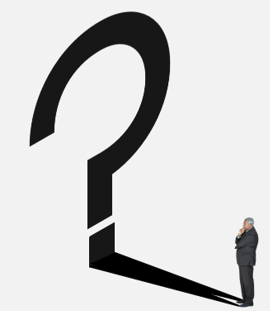

## **Assignment #2**: Code a MC Dropout-based version of ResNet18

In [8]:
class ResNetMC(tf.keras.Model):

    def __init__(self, num_classes=10, mc_dropout=None):
        super(ResNetMC, self).__init__()
        self.mc_dropout = mc_dropout
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlock(64, 2, downscale=False)
        self.block_c = ResnetBlock(128, 2)
        self.block_d = ResnetBlock(256, 2)
        self.block_e = ResnetBlock(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

        self.drop1 = tf.keras.layers.Dropout(self.mc_dropout) if self.mc_dropout else None
        self.drop2 = tf.keras.layers.Dropout(self.mc_dropout) if self.mc_dropout else None
        self.drop3 = tf.keras.layers.Dropout(self.mc_dropout) if self.mc_dropout else None
        self.drop4 = tf.keras.layers.Dropout(self.mc_dropout) if self.mc_dropout else None
        self.drop5 = tf.keras.layers.Dropout(self.mc_dropout) if self.mc_dropout else None

    def call(self, inputs):
        x = self.block_a(inputs)
        if self.mc_dropout:
            x = self.drop1(x, training = True)
        x = self.block_b(x)
        if self.mc_dropout:
            x = self.drop2(x, training = True)
        x = self.block_c(x)
        if self.mc_dropout:
            x = self.drop3(x, training = True)
        x = self.block_d(x)
        if self.mc_dropout:
            x = self.drop4(x, training = True)
        x = self.block_e(x)
        if self.mc_dropout:
            x = self.drop5(x, training = True)
        x = self.global_pool(x)
        return self.classifier(x)

## Load EMNIST

In [9]:
def show_images_from_npy(array, cmap=None):
    fig, ax = plt.subplots(1, 5)
    ax = ax.ravel()
    j = 0
    for idx in np.random.randint(0, array.shape[0], 5):
        ax[j].imshow(array[idx], cmap=cmap)
        ax[j].axis('off')
        j += 1
emnist = np.load(os.path.join(ROOTDIR_DATA, "emnist_images.npy"))
emnist_numpy = (emnist / 255).astype(np.float32)

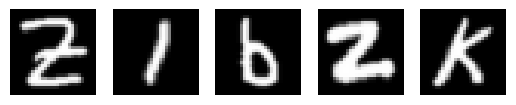

In [10]:
show_images_from_npy(emnist_numpy, cmap="gray")

N.B. Do not shuffle emnist

In [11]:
emnist = np.load(os.path.join(ROOTDIR_DATA, "emnist_images.npy"))
emnist_numpy = (emnist / 255).astype(np.float32)

In [12]:
preds_emnist = net.predict(emnist_numpy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step


## **Assignment #3**: Code a wrapper for a MC-based network
Implements:
1.   Several metrics to compute uncertainty
2.   Method to reierate predictions


In [13]:
class UncertaintyWrapper(tf.keras.Model):

    def __init__(self, num_classes=10, mc_dropout=None):
        super(UncertaintyWrapper, self).__init__()
        print(f"MC Dropout is set to {mc_dropout}")
        self.model = ResNetMC(mc_dropout=mc_dropout)
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy'] = self._entropy
        self._uncertainty_metrics['variance'] = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

    def call(self, inputs):
        return self.model(inputs)

    def uncertainty_metrics(self, multiple_preds):
        return {metric: self._compute_uncertainty(
            metric,
            multiple_preds) for metric in self._uncertainty_metrics.keys()}

    def _normalize(self, values):
            return (values - values.min())/(values.max()-values.min())

    def _compute_uncertainty(self, metric, multiple_preds):
        try:
            print("Done {}".format(metric))
            return self._normalize(
                self._uncertainty_metrics[metric](multiple_preds))
        except KeyError:
            print("{} not implemented.".format(metric))

    def predict_many_times(self, inputs, draws=2):
        preds = list()
        for _ in range(draws):
            pred = self.predict(inputs)
            preds.append(pred)
        return np.stack(preds)

    def _avreage_prediction(self, multiple_preds):
        m = np.mean(multiple_preds, axis=0)
        return m

    def _entropy(self, multiple_preds):
        avg_preds = self._avreage_prediction(multiple_preds)
        eps = 1e-5
        entropy = -1 * np.sum(avg_preds * np.log(avg_preds + eps), axis=1)
        return entropy

    def _variance(self, multiple_preds):
        avg_preds = self._avreage_prediction(multiple_preds)
        variance = np.var(avg_preds, axis=1)
        return variance

    def _max_softmax_response(self, multiple_preds):
        avg_preds = self._avreage_prediction(multiple_preds)
        max_softmax_response = np.max(avg_preds, axis=1)
        return max_softmax_response

In [14]:
net_unc = UncertaintyWrapper(mc_dropout=0.1)
net_unc.build((1, 28, 28, 1))
net_unc.summary()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
net_unc.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
net_unc.fit(mnist_train, epochs=1)
print("Accuracy on test set: {:.2f}".format(net_unc.evaluate(mnist_test)[1]))

MC Dropout is set to 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'uncertainty_wrapper', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "uncertainty_wrapper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ res_net_mc (ResNetMC)           │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - accuracy: 0.8846 - loss: 0.3656
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9546 - loss: 0.1459
Accuracy on test set: 0.95


## Compute MC predicitons and compare with *deterministic* uncertainty computation

In [15]:
multiple_preds_emnist = net_unc.predict_many_times(emnist, draws=10)
multiple_preds_mnist = net_unc.predict_many_times(mnist_test, draws=10)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [16]:
uncertainties = dict()
uncertainties_deterministic = dict()
uncertainties['mnist'] = net_unc.uncertainty_metrics(multiple_preds_mnist)
uncertainties['emnist'] = net_unc.uncertainty_metrics(multiple_preds_emnist)
uncertainties_deterministic['mnist'] = net_unc.uncertainty_metrics(np.expand_dims(preds_mnist, axis=0))
uncertainties_deterministic['emnist'] = net_unc.uncertainty_metrics(np.expand_dims(preds_emnist, axis=0))

Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


## **Assignment #4** Uncertainty metrics distributions for MNIST and EMNIST
Plot distributions in form of histograms


['entropy', 'variance', 'max_softmax_response']


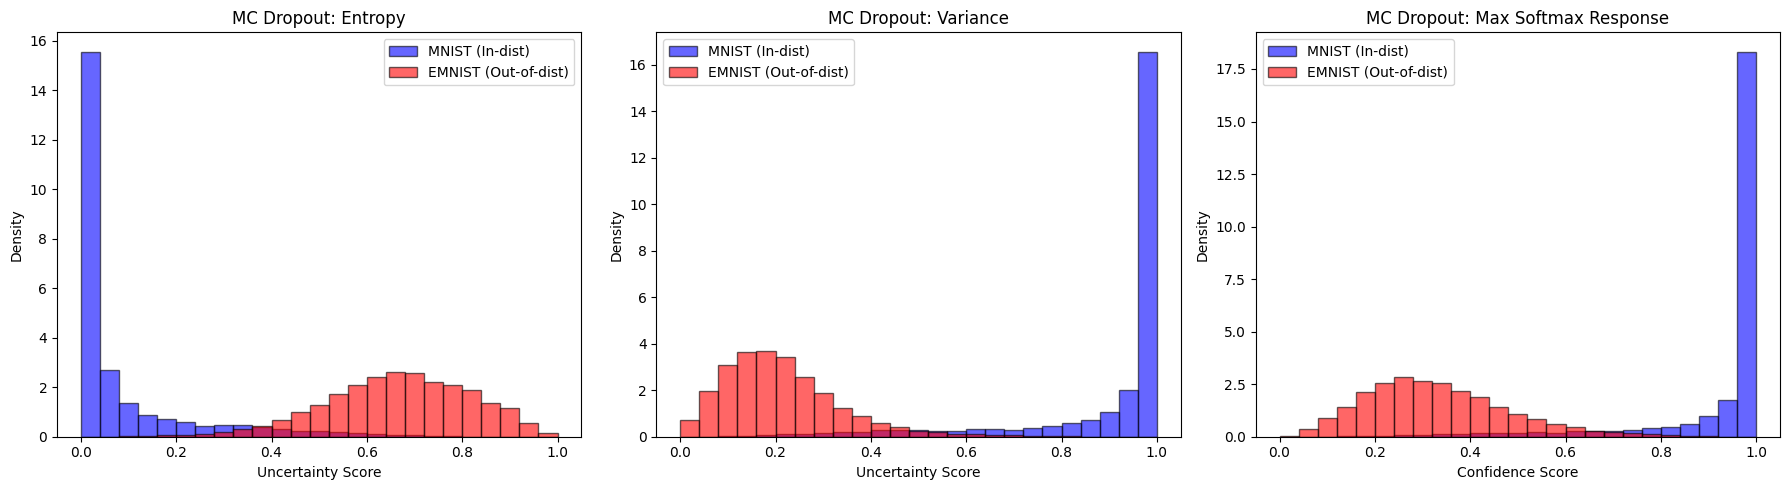

In [17]:
metrics = list(net_unc._uncertainty_metrics.keys())
print(metrics)

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))

for ax, measure in zip(axes, metrics):
    ax.set_title(f"MC Dropout: {measure.replace('_', ' ').title()}")

    ax.hist(uncertainties['mnist'][measure],
            color="blue",
            alpha=0.6,
            bins=25,
            label='MNIST (In-dist)',
            edgecolor='black',
            density=True)

    ax.hist(uncertainties['emnist'][measure],
            color="red",
            alpha=0.6,
            bins=25,
            label='EMNIST (Out-of-dist)',
            edgecolor='black',
            density=True)

    if measure == 'max_softmax_response':
        ax.set_xlabel("Confidence Score")
    else:
        ax.set_xlabel("Uncertainty Score")

    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

## **Assignment #5** Take a look at confident and not-confident predictions for EMNIST
Filter confident and not-confident images based on uncertainty values and plot some of them

Most Confident Predictions (Low Entropy):


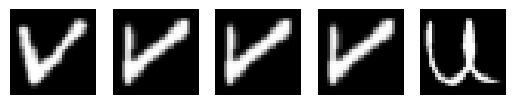

Least Confident Predictions (High Entropy):


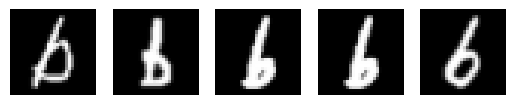

In [18]:
entropy_scores = uncertainties['emnist']['entropy']

most_confident_idx = np.argsort(entropy_scores)[:5]
least_confident_idx = np.argsort(entropy_scores)[-5:]

print("Most Confident Predictions (Low Entropy):")
show_images_from_npy(emnist_numpy[most_confident_idx], cmap="gray")
plt.show()

print("Least Confident Predictions (High Entropy):")
show_images_from_npy(emnist_numpy[least_confident_idx], cmap="gray")
plt.show()

# **Assignment #6** Uncertainty in DL - Ensamble
Populate a list of ResNet18 classifiers to create a group of expert (ignore indipendancy among datasets, i.e. different training cohorts).

In [19]:
nets = list()
num_models = 3

for i in range(num_models):
    print(f"--- Training Expert {i+1}/{num_models} ---")
    net = ResNet()
    net.build((1, 28, 28, 1))

    net.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    net.fit(mnist_train, epochs=5, validation_data=mnist_test)

    nets.append(net)

--- Training Expert 1/3 ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 69s 13ms/step - accuracy: 0.9413 - loss: 0.1959 - val_accuracy: 0.9749 - val_loss: 0.1015
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - accuracy: 0.9801 - loss: 0.0769 - val_accuracy: 0.9876 - val_loss: 0.0538
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.9837 - loss: 0.0619 - val_accuracy: 0.9868 - val_loss: 0.0517
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9863 - loss: 0.0524 - val_accuracy: 0.9890 - val_loss: 0.0364
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 52s 14ms/step - accuracy: 0.9886 - loss: 0.0423 - val_accuracy: 0.9866 - val_loss: 0.0513
--- Training Expert 2/3 ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 71s 14ms/step - accuracy: 0.9444 - loss: 0.1886 - val_accuracy: 0.9872 - val_loss: 0.0449
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.9790 - loss: 0.0802 - val_accuracy: 0.9874 - val_loss: 0.0472
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9833 - loss: 0.0612 - val_accuracy: 0.9869 - val_loss: 0.0473
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.9865 - loss: 0.0523 - val_accuracy: 0.9852 - val_loss: 0.0509
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.9882 - loss: 0.0424 - val_accuracy: 0.9890 - val_loss: 0.0455
--- Training Expert 3/3 ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'res_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 71s 13ms/step - accuracy: 0.9382 - loss: 0.2021 - val_accuracy: 0.9809 - val_loss: 0.0703
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9792 - loss: 0.0767 - val_accuracy: 0.9818 - val_loss: 0.0598
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 49s 13ms/step - accuracy: 0.9836 - loss: 0.0609 - val_accuracy: 0.9851 - val_loss: 0.0478
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - accuracy: 0.9867 - loss: 0.0508 - val_accuracy: 0.9848 - val_loss: 0.0528
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 48s 13ms/step - accuracy: 0.9876 - loss: 0.0526 - val_accuracy: 0.9807 - val_loss: 0.0672


In [20]:
emnist_preds_ensamble = list()
mnist_preds_ensamble = list()
for net in nets:
    emnist_preds_ensamble.append(net.predict(emnist))
    mnist_preds_ensamble.append(net.predict(mnist_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step


In [21]:
uncertainties_ensable = dict()
uncertainties_ensable['mnist'] = net_unc.uncertainty_metrics(np.array(mnist_preds_ensamble))
uncertainties_ensable['emnist'] = net_unc.uncertainty_metrics(np.array(emnist_preds_ensamble))

Done entropy
Done variance
Done max_softmax_response
Done entropy
Done variance
Done max_softmax_response


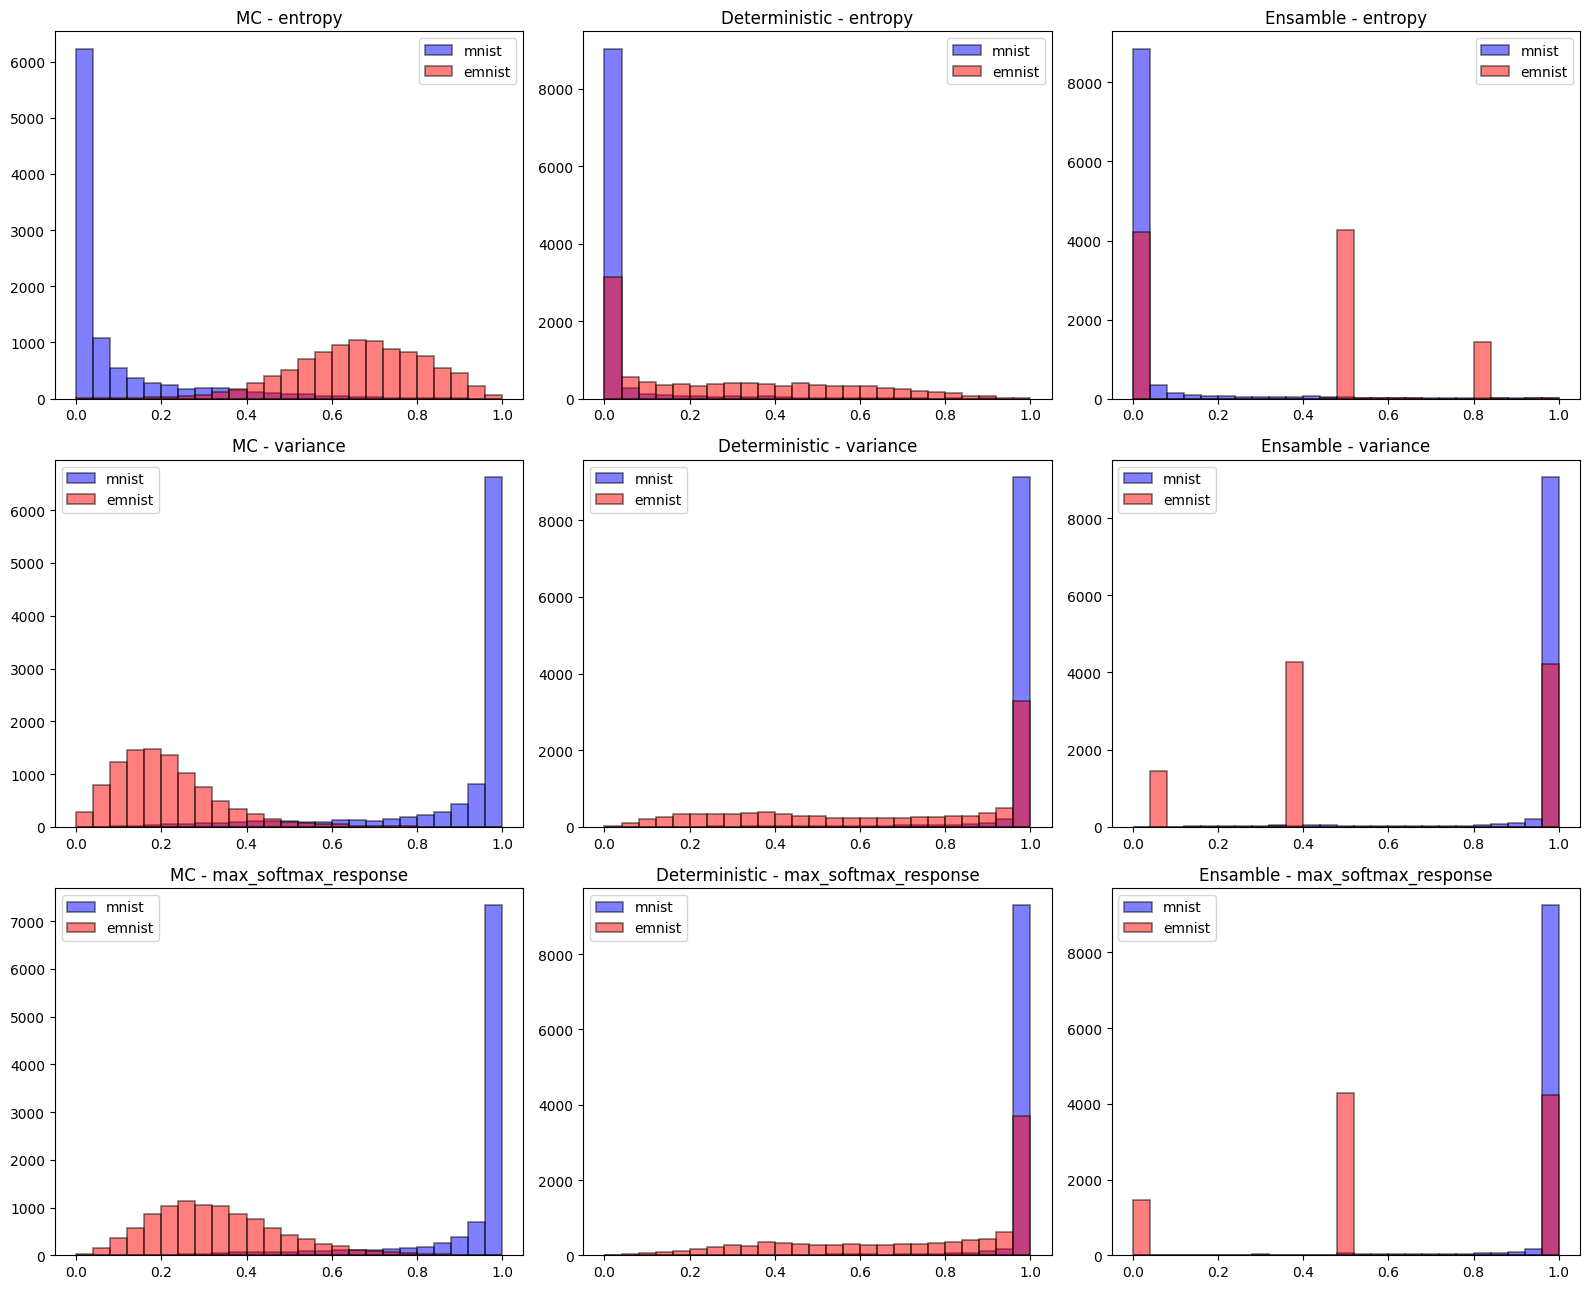

In [22]:
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 3, figsize=(16, 13))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0].set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1].set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2].set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
plt.tight_layout()

In [23]:
import tensorflow_probability as tfp
#
tfd = tfp.distributions
NUM_TRAIN_EXAMPLES = 50000
NUM_CLASSES = 10
LR = 0.01

# Uncertainty in DL - Variational Inference

In [24]:
class ResidualVI(tf.keras.Model):
    """The Residual block of ResNet."""

    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.kl_divergence_function = (lambda q, p, _: tfd.kl_divergence(q, p) /
                                       tf.cast(NUM_TRAIN_EXAMPLES, dtype=tf.float32))
        self.conv1 = tfp.layers.Convolution2DFlipout(
            num_channels,
            kernel_size=3,
            padding='same',
            strides=strides,
            kernel_divergence_fn=self.kl_divergence_function,
            activation=tf.nn.relu)
        self.conv2 = tfp.layers.Convolution2DFlipout(
            num_channels,
            kernel_size=3,
            padding='same',
            kernel_divergence_fn=self.kl_divergence_function,
            activation=tf.nn.relu)
        self.conv_1x1 = None
        if use_1x1conv:
            self.conv_1x1 = tf.keras.layers.Conv2D(
                num_channels,
                kernel_size=1,
                strides=strides)

            self.conv_1x1 = tfp.layers.Convolution2DFlipout(
                num_channels,
                kernel_size=1,
                strides=strides,
                kernel_divergence_fn=self.kl_divergence_function)

        self.bn1 = tf.keras.layers.BatchNormalization()
        self.bn2 = tf.keras.layers.BatchNormalization()

    def call(self, X):
        Y = tf.keras.activations.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv_1x1 is not None:
            X = self.conv_1x1(X)
        Y += X
        return tf.keras.activations.relu(Y)

class ResnetBlockVI(tf.keras.layers.Layer):
    def __init__(self, num_channels, num_residuals, downscale=True, **kwargs):
        super(ResnetBlockVI, self).__init__(**kwargs)
        self.residual_layers = []
        for i in range(num_residuals):
            if i == 0 and downscale:
                self.residual_layers.append(
                    ResidualVI(num_channels, use_1x1conv=True, strides=2))
            else:
                self.residual_layers.append(ResidualVI(num_channels))

    def call(self, X):
        for layer in self.residual_layers:
            X = layer(X)
        return X

class ResNetVI(tf.keras.Model):

    def __init__(self, num_classes=10):
        super(ResNetVI, self).__init__()
        self.block_a = tf.keras.Sequential(
            [tf.keras.layers.Conv2D(64,
                                    kernel_size=7,
                                    strides=2,
                                    padding='same'),
             tf.keras.layers.BatchNormalization(),
             tf.keras.layers.MaxPool2D(pool_size=3,
                                       strides=2,
                                       padding='same')])
        self.block_b = ResnetBlockVI(64, 2, downscale=False)
        self.block_c = ResnetBlockVI(128, 2)
        self.block_d = ResnetBlockVI(256, 2)
        self.block_e = ResnetBlockVI(512, 2)
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")

    def call(self, inputs):
        x = self.block_a(inputs)
        x = self.block_b(x)
        x = self.block_c(x)
        x = self.block_d(x)
        x = self.block_e(x)
        x = self.global_pool(x)
        return self.classifier(x)

In [25]:
class VIWrapper(UncertaintyWrapper):
    def __init__(self, num_classes=10):
        tf.keras.Model.__init__(self)
        print("VI Wrapper initialized")
        self.model = ResNetVI(num_classes=num_classes)
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy']              = self._entropy
        self._uncertainty_metrics['variance']             = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

    def call(self, inputs):
        return self.model(inputs)

In [26]:
net_vi = VIWrapper()
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
# The Keras API will automatically add the
# Kullback-Leibler divergence (contained on the individual layers of
# the model), to the cross entropy loss, effectively
# calcuating the (negated) Evidence Lower Bound Loss (ELBO)
net_vi.compile(optimizer, loss='categorical_crossentropy',
               metrics=['accuracy'], run_eagerly=True)

VI Wrapper initialized


In [31]:
import gc

tf.keras.backend.clear_session()
gc.collect()

0

In [32]:
net_vi.fit(mnist_train, epochs=3)

# I encountered an error and attempted to resolve it by reducing the batch_size to 32, 16, and 8, but the issue persists.

Epoch 1/3


ResourceExhaustedError: Exception encountered when calling layer 'conv2d_flipout_18' (type Conv2DFlipout).

{{function_node __wrapped__Mul_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:Mul] name: 

Call arguments received by layer 'conv2d_flipout_18' (type Conv2DFlipout):
  • inputs=tf.Tensor(shape=(16, 1, 1, 512), dtype=float32)

In [ ]:
print("Accuracy on test set: {:.2f}".format(net_vi.evaluate(mnist_test)[1]))
preds_mnist = net_vi.predict(mnist_test)

In [ ]:
vi_preds_emnist = net_vi.predict_many_times(emnist, draws=10)
vi_preds_mnist = net_vi.predict_many_times(mnist_test, draws=10)

In [ ]:
uncertainties_vi = dict()
uncertainties_vi['mnist'] = net_unc.uncertainty_metrics(np.array(vi_preds_mnist))
uncertainties_vi['emnist'] = net_unc.uncertainty_metrics(np.array(vi_preds_emnist))

In [ ]:
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 4, figsize=(21, 11))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0] .set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1] .set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2] .set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
    ax[3] .set_title(f"VI - {measure}")
    ax[3].hist(uncertainties_vi['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[3].hist(uncertainties_vi['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[3].legend()
plt.tight_layout()

# **Assignment #7** Uncertainty in DL - Test Time Augmentation-Based
See [data augmentation for tensorflow and keras](https://www.tensorflow.org/tutorials/images/data_augmentation) to implement some data augmentation techniques.

In [ ]:
class TTAWrapper(UncertaintyWrapper):
    def __init__(self, num_classes=10):
        super(TTAWrapper, self).__init__()
        self.model = ResNet()
        self._uncertainty_metrics = dict()
        self._uncertainty_metrics['entropy'] = self._entropy
        self._uncertainty_metrics['variance'] = self._variance
        self._uncertainty_metrics['max_softmax_response'] = self._max_softmax_response

    def call(self, inputs):
        return self.model(inputs)

    def predict_many_times(self, ds, policy, repeat=1):
        pred_augmented = list()


        policy_identity = [tf.keras.Sequential([
            tf.keras.layers.Layer()])]

        policy_random_crop = [tf.keras.Sequential([
            tf.keras.layers.ZeroPadding2D(padding=2),
            tf.keras.layers.RandomCrop(28, 28)
        ])]

        policy_random_flip = [tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal")
        ])]

        policy_random_contrast = [tf.keras.Sequential([
            tf.keras.layers.RandomContrast(factor=0.3)
        ])]

        policy_random_zoom = [tf.keras.Sequential([
            tf.keras.layers.RandomZoom(height_factor=(-0.1, 0.1),
                                       width_factor=(-0.1, 0.1))
        ])]

        policies = dict()
        policies['identity'] = policy_identity
        policies['random_crop'] = policy_random_crop
        policies['random_contrast'] = policy_random_contrast
        policies['random_zoom'] = policy_random_zoom
        policies['random_flip'] = policy_random_flip

        policies['random_crop'] = sum([policies['random_crop'] for _ in range(repeat)], [])
        policies['random_contrast'] = sum([policies['random_contrast'] for _ in range(repeat)], [])
        policies['random_zoom'] = sum([policies['random_zoom'] for _ in range(repeat)], [])
        policies['random_flip'] = sum([policies['random_flip'] for _ in range(repeat)], [])

        for p in policies[policy]:
            ds_augmented = ds.map(lambda x, y: (p(x, training=True), y))
            pred_augmented.append(self.predict(ds_augmented))

        return pred_augmented

In [ ]:
net_tta = TTAWrapper()
net_tta.build((1, 28, 28, 1))
net_tta.summary()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
net_tta.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics="accuracy")
net_tta.fit(mnist_train, epochs=3)
print("Accuracy on test set: {:.2f}".format(net_tta.evaluate(mnist_test)[1]))

In [ ]:
emnist_preds_tta = net_tta.predict_many_times(emnist, "random_zoom", repeat=10)
mnist_preds_tta = net_tta.predict_many_times(mnist_test, "random_zoom", repeat=10)

In [ ]:
uncertainties_tta = dict()
uncertainties_tta['mnist'] = net_tta.uncertainty_metrics(np.array(mnist_preds_tta))
uncertainties_tta['emnist'] = net_tta.uncertainty_metrics(np.array(emnist_preds_tta))
fig, axes = plt.subplots(len(net_unc._uncertainty_metrics.keys()), 5, figsize=(21, 11))
for ax, measure in zip(axes, net_unc._uncertainty_metrics.keys()):
    ax[0].set_title(f"MC - {measure}")
    ax[0].hist(uncertainties['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[0].hist(uncertainties['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[0].legend()
    ax[1].set_title(f"Deterministic - {measure}")
    ax[1].hist(uncertainties_deterministic['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[1].hist(uncertainties_deterministic['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[1].legend()
    ax[2].set_title(f"Ensamble - {measure}")
    ax[2].hist(uncertainties_ensable['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[2].hist(uncertainties_ensable['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[2].legend()
    ax[3].set_title(f"VI - {measure}")
    ax[3].hist(uncertainties_vi['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[3].hist(uncertainties_vi['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[3].legend()
    ax[4].set_title(f"TTA - {measure}")
    ax[4].hist(uncertainties_tta['mnist'][measure], color="blue", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="mnist");
    ax[4].hist(uncertainties_tta['emnist'][measure], color="red", log=False, bins=25, edgecolor='black', linewidth=1.2, alpha=0.5, label="emnist");
    ax[4].legend()
plt.tight_layout()